# Deep Dive: Random Sample Imputation (Comprehensive: Numerical & Categorical)

Random Sample Imputation is a univariate technique that replaces missing values by randomly drawing from the pool of existing, non-missing observations within the same column.

It treats the column's known data as an empirical probability distribution, making it unique because it applies identically to both **Numerical** and **Categorical** variables.

---

## 1. Core Mechanics: How It Works

When a feature column contains missing values (`NaN`), the algorithm isolates the available, non-missing values and samples from them with replacement. 

### Probability Matching Feature

Because values are sampled directly from the existing data pool, observations that occur more frequently have a proportionally higher mathematical chance of being selected. 

*   **Numerical Example:** If 80% of your known dataset has an `Age` between 20 and 30, the random sampler has an 80% chance of picking a number in that exact range to fill any empty slot.

*   **Categorical Example:** If a `Subscription_Plan` column is distributed as 70% `Basic`, 20% `Premium`, and 10% `Free`, the random sampler has a 70% chance of selecting `Basic` for an empty cell, a 20% chance for `Premium`, and a 10% chance for `Free`.

> NOTE: Scikit-learn does **not** feature a native class for random sample imputation. It must be executed  using custom code or Pandas pipelines:


---

## 2. Prerequisites for Use (When to Apply)

1.  **MCAR (Missing Completely At Random):** The data must be missing purely by chance. If a specific group of people systematically hid their data, sampling from the remaining pool will simply replicate and amplify that collection bias.

2.  **Linear, Distance, or Statistical Models:** This method is highly effective when your final model (such as Linear Regression, Logistic Regression, or Support Vector Machines) depends heavily on the strict preservation of the feature's natural distribution shape.

---

## 3. Advantages (Benefits)

### A. Preservation of Variance and Standard Deviation (Numerical)
Unlike mean or median imputation—which artificially bundles hundreds of missing rows into a single constant value and collapses data variance—random sample imputation spreads the injected values across the entire natural range of your data. The column's overall variance remains statistically unchanged.

### B. Maintenance of Category Balance (Categorical)
Mode imputation over-inflates and exaggerates the dominant category. Random sample imputation completely preserves the original percentage breakdown (the proportions) of your categories, ensuring your data summaries and pie charts look completely unaltered before and after imputation.

### C. No Distribution Distortion
Because the values are mirrored from the real data, the overall shape of the histogram or frequency chart (whether it is normal, heavily skewed, or bimodal) is perfectly preserved. It introduces no artificial "spikes."

---

## 4. Disadvantages and Risks (Why to Avoid)

### A. Total Instability in Production (Non-Deterministic)
Because this method relies on random selection, running the exact same raw data row through your deployment pipeline twice can yield two completely different imputed values. 

*   **The Deployment Risk:** A customer applying for a credit card could get approved at 9:00 AM and denied at 9:05 AM simply because the random sampler pulled a `750` credit score the first time and a `580` credit score the second time to fill a blank field in their application.

### B. Severe Disruption of Covariance (The Relationship Clash)
While this method preserves the distribution of an *individual* column perfectly, it completely ignores the relationships *between* columns. It breaks joint logic rules across your dataset.

*   **Numerical Mismatch Example:** If a row represents a 16-year-old high school student whose `Income` is missing, the random sampler might pull a value from a 55-year-old corporate executive's row. Your machine learning model is now forced to train on an impossible profile: a 16-year-old making \$200,000 a year.

*   **Categorical Mismatch Example:** If a customer's `Country` column is missing, the random sampler might pull `"India"` for a row where the `Zip_Code`, `State`, and `Currency` columns explicitly point to `"Germany"`, feeding corrupted, conflicting information to your machine learning algorithm.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### 1. Numerical data


In [4]:
# Import the dataset
df = pd.read_csv("../data/titanic.csv", usecols=["Age", "Fare", "Survived"])
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
# Percentage of Missing Value
df.isnull().mean()*100


Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
# Split the dataset into training and testing sets
X = df.drop("Survived", axis=1)
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (712, 2)
Testing set shape: (179, 2)


In [7]:
# Make New Column to evaluate the changes
X_train["Age_imputed"] = X_train["Age"]
X_test["Age_imputed"] = X_test["Age"]

In [9]:
# Filling missing values by selecting random values from the same column

train_missing = X_train["Age_imputed"].isna()
test_missing = X_test["Age_imputed"].isna()

train_values = X_train["Age"].dropna().sample(
    n=train_missing.sum(),
    random_state=44
).to_numpy()
X_train.loc[train_missing, "Age_imputed"] = train_values

test_values = X_test["Age"].dropna().sample(
    n=test_missing.sum(),
    random_state=44
).to_numpy()
X_test.loc[test_missing, "Age_imputed"] = test_values

X_train.isnull().mean()*100

Age            19.662921
Fare            0.000000
Age_imputed     0.000000
dtype: float64

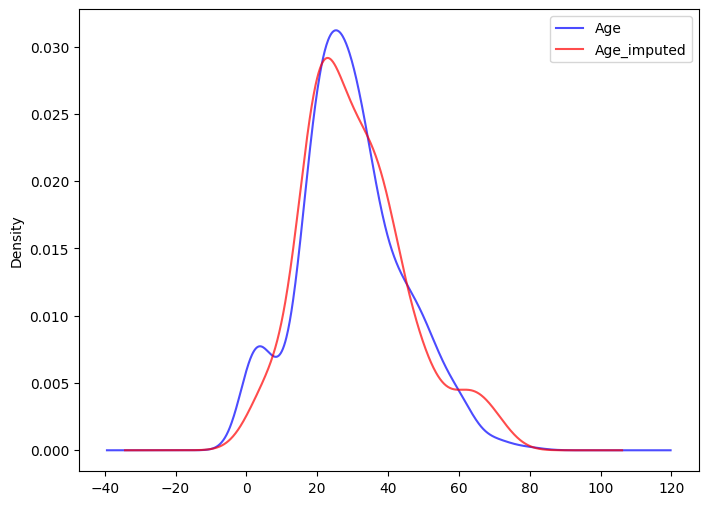

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
X_train["Age"].plot(kind="kde" , alpha=0.7, color='blue', ax=ax)
X_test["Age_imputed"].plot(kind="kde", alpha=0.7, color='red', ax=ax)
plt.legend()
plt.show()



In [17]:
print(f"Original variance : {X_train['Age'].var()}")
print(f"Variance after imputation : {X_train['Age_imputed'].var()}")

Original variance : 210.2517072477435
Variance after imputation : 210.4735711815926


In [19]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2700.831981,71.580633,54.857635
Age,71.580633,210.251707,210.251707
Age_imputed,54.857635,210.251707,210.473571


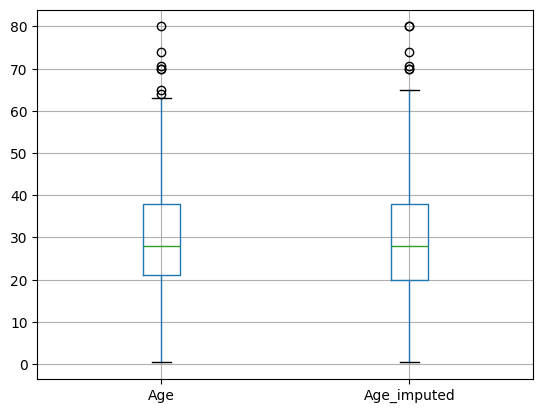

In [21]:
X_train[['Age', 'Age_imputed']].boxplot()
plt.show()

### 2. Categorical data

In [45]:
# Importing DataSet
data = pd.read_csv("../data/House.csv", usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [46]:
# Percentage Missing Values
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [47]:
X = data
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set size : {len(X_train)}")
print(f"Test set size : {len(X_test)}")

Train set size : 1168
Test set size : 292


In [48]:
X_train.head(2)

,FireplaceQu,GarageQual,SalePrice
254,NaN,TA,145000
1066,TA,TA,178000


In [49]:
X_train["GarageQual_imputed"] = X_train["GarageQual"]
X_test["GarageQual_imputed"] = X_test["GarageQual"]

X_train["FireplaceQu_imputed"] = X_train["FireplaceQu"]
X_test["FireplaceQu_imputed"] = X_test["FireplaceQu"]



In [ ]:
# Imputing Missing Values in Categorical Features
def impute_category(X_train, X_test, feature, imputed_feature):
    """
    Imputes missing values in a categorical feature using the mode of the non-missing values."""
    
    train_missing = X_train[imputed_feature].isna()
    test_missing = X_test[imputed_feature].isna()

    train_values = X_train[feature  ].dropna().sample(
        n=train_missing.sum(),
        random_state=44
    ).to_numpy()
    X_train.loc[train_missing, imputed_feature] = train_values

    test_values = X_test[feature].dropna().sample(
        n=test_missing.sum(),
        random_state=44
    ).to_numpy()
    X_test.loc[test_missing, imputed_feature] = test_values

impute_category(X_train, X_test, "FireplaceQu", "FireplaceQu_imputed")
impute_category(X_train, X_test, "GarageQual", "GarageQual_imputed")

In [51]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
780,TA,TA,176000,TA,TA
1153,NaN,TA,120500,TA,Gd
748,TA,TA,260400,TA,TA
561,TA,TA,170000,TA,TA
1311,NaN,TA,203000,TA,TA


In [ ]:
# frequency change
def freq_change(X, feature, imputed_feature):
    """
    Imputes missing values in a categorical feature using the mode of the non-missing values."""
    
    featured_count = X[feature].value_counts(normalize=False)/ len(X[feature].dropna())
    imputed_feature_count =X[imputed_feature].value_counts(normalize=False) / len(X)
    diff=abs((imputed_feature_count - featured_count))
    
    freq = pd.concat([
        featured_count,
        imputed_feature_count,
        diff
    ], axis=1)
    
    freq.columns = ["Original Frequency", "Imputed Frequency", "Difference"]
    
    return freq
    


In [76]:
freq_FireplaceQu =freq_change(X_train, "FireplaceQu", "FireplaceQu_imputed")    
freq_FireplaceQu

,Original Frequency,Imputed Frequency,Difference
Gd,0.491143,0.493151,0.002007
TA,0.405797,0.405822,0.000025
Fa,0.043478,0.042808,0.000670
Ex,0.033816,0.033390,0.000426
Po,0.025765,0.024829,0.000936


In [77]:
freq_GarageQual =freq_change(X_train, "GarageQual", "GarageQual_imputed")
freq_GarageQual

,Original Frequency,Imputed Frequency,Difference
TA,0.951087,0.952911,0.001824
Fa,0.032609,0.030822,0.001787
Gd,0.011775,0.011130,0.000645
Ex,0.002717,0.002568,0.000149
Po,0.001812,0.002568,0.000757


In [ ]:
# Distribution Plots for Target Variable with Imputed Feature
def dist_plot(X, col, imputed_col, target):
    
    plt.figure(figsize=(14, 4))
    
    plt.subplot(121)
    sns.kdeplot(
        data=X,
        x=target,
        hue=col,
        common_norm=False
    )
    plt.title(f"{target} Distribution by {col}")

    plt.subplot(122)
    sns.kdeplot(
        data=X,
        x=target,
        hue=imputed_col,
        common_norm=False
    )
    plt.tight_layout()
    plt.show()


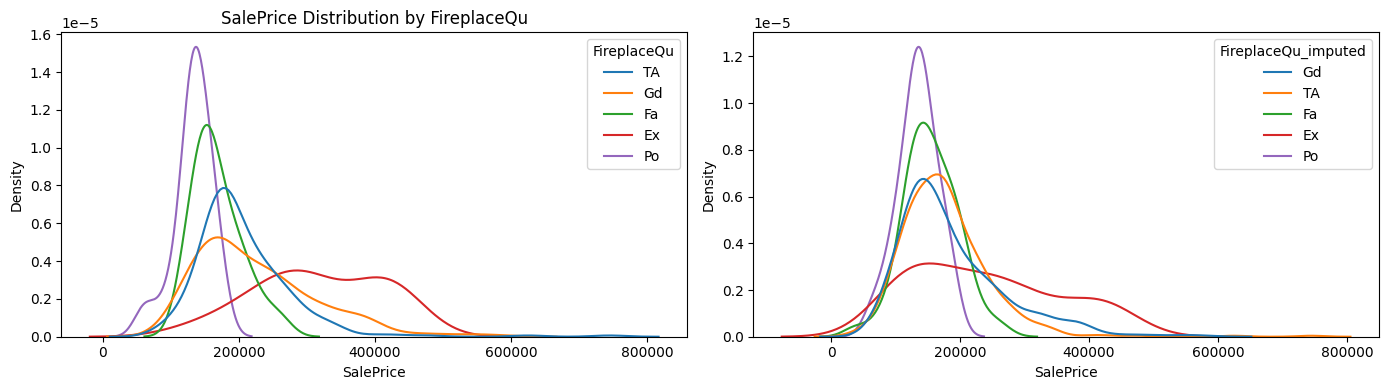

In [94]:
dist_plot(X_train, "FireplaceQu", "FireplaceQu_imputed", "SalePrice")    

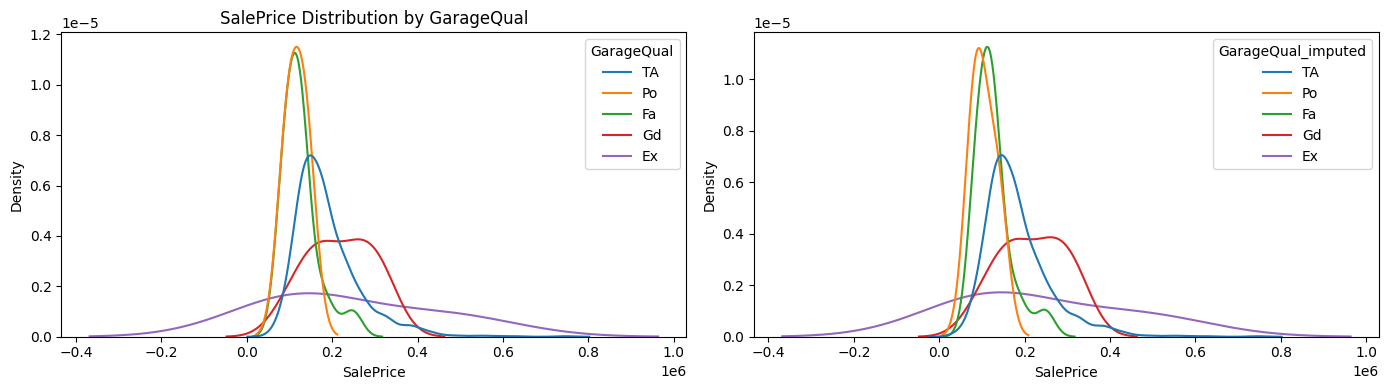

In [95]:
dist_plot(X_train, "GarageQual", "GarageQual_imputed", "SalePrice")

# Model Compatibility: When to Use vs. Avoid Random Sample Imputation

Because Random Sample Imputation preserves the individual distribution shape but completely destroys the logical relationships between columns, it interacts uniquely with different families of machine learning algorithms. 

---

## 1. Algorithms That Can Utilize This Technique

These models benefit from Random Sample Imputation because they are highly sensitive to changes in data variance, standard deviation, and overall distribution shapes.

### Linear Models (Linear Regression, Logistic Regression, Ridge/Lasso)

*   **Why it works:** Linear models rely heavily on the assumption of data variance. Mean or median imputation creates a massive artificial "spike" at the center, collapsing variance and diluting the slope coefficients ($W$). Random sample imputation preserves the spread of data, allowing the linear weights to stay truer to the original distribution.

### Distance-Based Algorithms (KNN, K-Means Clustering, SVMs)

*   **Why it works:** Algorithms that calculate geometric distance (like Euclidean distance) are easily warped by constant-value imputations (like `-999` or extreme end-of-distribution tails), which create massive artificial spatial clusters. Random sample imputation keeps data points naturally distributed across the coordinate space, preventing distance metrics from breaking down.

### Neural Networks (Deep Learning)
*   **Why it works:** Neural networks can struggle during training if feature standard deviations are artificially squashed by a heavy influx of identical values (like the mean). Preserving the standard deviation across columns keeps gradient descent optimizations smoother and more stable.

---

## 2. Algorithms That CANNOT (or Should Not) Utilize This Technique

These algorithms struggle with Random Sample Imputation because they rely heavily on interaction patterns and logical cross-column relationships, which this technique actively breaks.

### Tree-Based Models (Decision Trees, Random Forests, XGBoost, LightGBM, CatBoost)

*   **Why it fails:** Tree algorithms look for exact feature interactions (e.g., `if Age < 21 AND Income > 50,000`). Random sample imputation creates logical mismatches—like assigning a 16-year-old student an executive's salary. Tree-based models will waste splits trying to learn these impossible, randomly generated patterns, which ruins their predictive accuracy on real-world data.

*   **Better Alternative:** Use **Arbitrary Value** (`-999`) or **End of Distribution** imputation instead. Tree models thrive when missing values are packed into a single extreme bucket.

### Rule-Based Models & Association Learners (Apriori, FP-Growth)

*   **Why it fails:** These models find frequent itemsets and logical rules (e.g., `if Product = 'Diapers', then Category = 'Baby'`). If a missing category is filled with a random sample like `'Automotive'`, the algorithm will generate corrupted, useless business rules.

*   **Better Alternative:** Use **"Missing" Label / Constant Imputation** to keep rules coherent.

### High-Risk Production Frameworks (Any Model in Live Deployment)

*   **Why it fails:** If your deployment framework requires consistency and determinism, this method is fundamentally unsafe. Because it relies on a random number generator, passing the exact same customer profile through the model twice could yield completely different predictions simply because the imputer picked a different random number to fill a blank spot.

---

## 3. Quick Reference Matrix

| Algorithm Family | Compatibility Status | Core Reason |
| :--- | :--- | :--- |
| **Linear Regression / Logistic** | ✅ Recommended | Preserves data variance and protects coefficient slopes. |
| **K-Nearest Neighbors (KNN)** | ✅ Compatible | Prevents geometric distance calculations from collapsing. |
| **Support Vector Machines (SVM)** | ✅ Compatible | Maintains natural spatial distribution across the margin. |
| **Neural Networks / MLP** | ✅ Compatible | Keeps feature scales and standard deviations steady. |
| **Decision Trees / Random Forests** | ❌ Avoid | Creates logical column mismatches that confuse tree splits. |
| **Gradient Boosting (XGBoost)** | ❌ Avoid | Wastes model capacity learning artificial, randomized patterns. |
| **Live Production Deployments** | ❌ Avoid | Non-deterministic nature causes unstable, unpredictable model outputs. |


# =======================================================================================


# Deep Dive: Missing Indicator Imputation

A Missing Indicator is an advanced feature-engineering strategy rather than a traditional filling method. Instead of trying to guess the missing value, this technique explicitly creates a new binary column (flag) that tracks whether a value was originally missing. It is almost always used in tandem with a traditional univariate imputer (like mean or median).

---

## 1. Core Mechanics: How It Works

When a feature column (e.g., `Age`) contains missing values (`NaN`), the process executes a two-step transformation:

1.  **Binary Flag Generation:** A new Boolean or integer column is appended to the dataset (typically named `Age_was_missing`). For every row where `Age` is valid, this column gets a `0` (False). For every row where `Age` is `NaN`, it gets a `1` (True).

2.  **Primary Imputation:** The original missing values in the `Age` column are then filled using a standard univariate baseline (typically **Median** or **Mean**).

### Scikit-Learn Implementation
Scikit-learn provides two native ways to implement this. We can use the dedicated `MissingIndicator` class to generate just the flags, or use the `add_indicator=True` parameter directly inside `SimpleImputer` to perform both steps simultaneously.


```python
from sklearn.impute import SimpleImputer

# Automatically imputes the column AND appends a binary '_was_missing' flag column
imputer = SimpleImputer(strategy='median', add_indicator=True)

# Example execution on your feature matrix
# X_transformed = imputer.fit_transform(X)
```

---

## 2. Prerequisites for Use (When to Apply)

1.  **MNAR (Missing Not At Random):** This technique is specifically engineered for data where the missingness itself contains a strong hidden signal or business meaning. For example, if older medical patients routinely skip an optional physical endurance question, the *absence* of that data is a strong predictor of health status.

2.  **Hybrid Datasets:** When your dataset contains a mix of columns—some where data is missing completely by chance (MCAR) and others where it is missing systematically (MNAR).

---

## 3. Advantages (Benefits)

### A. Zero Information Loss

Traditional methods like mean or median imputation completely erase the pattern of missingness, hiding the fact that a gap ever existed. A Missing Indicator preserves 100% of this predictive behavior, allowing downstream machine learning models to leverage the missingness pattern directly.

### B. Neutralizes the Flaws of Mean/Median Imputation

As established previously, mean/median imputation distorts data distributions by forcing an artificial "spike" at the center. By pairing it with a Missing Indicator, you protect your model. The model learns to interpret the artificial mean values differently whenever the companion indicator column is set to `1`.

### C. Highly Deterministic & Stable

Because there is zero randomness involved, this method is perfectly deterministic, making it exceptionally reliable and safe for production scoring systems.

---

## 4. Disadvantages and Risks (Why to Avoid)

### A. Dimensionality Explosion (Feature Bloat)

If we turn on `add_indicator=True` blindly across a massive dataset with hundreds of columns containing sporadic missing values, scikit-learn will double our feature count by creating a binary flag for every single column. This significantly increases model training times and memory consumption.

### B. Collinearity Risks

If two or more columns always tend to be missing together (e.g., if a customer skips a survey, five different optional fields all become `NaN` simultaneously), their corresponding missing indicator columns will be completely identical. This creates perfect multicollinearity, which can destabilize certain mathematical models.

---

## 5. Model Compatibility Matrix

| Algorithm Family | Compatibility Status | Core Reason |
| :--- | :--- | :--- |
| **Decision Trees / Random Forests** | ✅ Highly Recommended | Tree models love binary splits. A single split on `Age_was_missing == 1` allows the tree to isolate and route missing profiles instantly. |
| **Gradient Boosting (XGBoost / LightGBM)** | ✅ Highly Recommended | Allows boosting algorithms to build highly precise, conditional leaf paths tailored specifically around omitted data behaviors. |
| **Linear / Logistic Regression** | ✅ Compatible | Safely processes the binary `0/1` feature as an intercept shift, though you must watch out for multicollinearity among flags. |
| **Neural Networks / MLP** | ✅ Compatible | Easily processes the flag as an additional structural feature to adjust internal weight nodes. |
| **Distance-Based (KNN / SVM)** | ⚠️ Use with Caution | Adding multiple binary `0/1` dimensions alters geometric space. A scale mismatch between the real feature and the binary flag can distort distance calculations if not properly normalized. |


In [ ]:
# Importing Data
data = pd.read_csv("../data/titanic.csv", usecols=['Age', 'Fare', 'Survived'])
data.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
# Split Data into Features and Target Variable
X = data.drop(columns=['Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))


Training set size: 712
Test set size: 179


In [ ]:

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression Model
def apply_model(X_train, X_test, apply_strategy='mean'):
    si = SimpleImputer(strategy=apply_strategy)

    X_train_trf = si.fit_transform(X_train)
    X_test_trf = si.transform(X_test)

    X_train_trf = pd.DataFrame(X_train_trf, columns=X_train.columns)
    X_test_trf = pd.DataFrame(X_test_trf, columns=X_test.columns)
    
    clf = LogisticRegression(max_iter=1000)

    clf.fit(X_train_trf, y_train)
    y_pred = clf.predict(X_test_trf)

    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

apply_model(X_train, X_test, 'mean')

Accuracy: 0.6480446927374302


In [170]:
from sklearn.impute import MissingIndicator

mi = MissingIndicator()
mi.fit(X_train)

X_train_missing = mi.transform(X_train)
X_test_missing = mi.transform(X_test)

# Finding Column that contains Missing Values 
print(f"Columns with Missing Values: {mi.features_}")

Columns with Missing Values: [0]


In [171]:
# Make a new Column for the missing indicator
X_train['Age_NA'] = X_train_missing
X_test['Age_NA'] = X_test_missing

X_train.sample(5)

,Age,Fare,Age_NA
34,28.0,82.1708,False
441,20.0,9.5000,False
715,19.0,7.6500,False
503,37.0,9.5875,False
178,30.0,13.0000,False


In [ ]:
# Accuracy without Imputation
apply_model(X_train, X_test, 'mean')

Accuracy: 0.6368715083798883


#### Without using MissingIndicator Class

In [ ]:
# using SimpleImputer Class
X_train = X_train.drop(columns=['Age_NA'])
X_test = X_test.drop(columns=['Age_NA'])


# Imputing the missing values using SimpleImputer Class
si = SimpleImputer(add_indicator=True)
si.fit(X_train)
X_train_si = si.transform(X_train)
X_test_si = si.transform(X_test)



In [ ]:
X_train_si = pd.DataFrame(X_train_si, columns=['Age', 'Fare', 'Age_NA'])
X_test_si = pd.DataFrame(X_test_si, columns=['Age', 'Fare', 'Age_NA'])

# Accuracy with Imputation using SimpleImputer Class
apply_model(X_train_si, X_test_si)

Accuracy: 0.6368715083798883


# =======================================================================================


# Deep Dive: Automated Imputation Selection Using GridSearchCV

Using `GridSearchCV` for imputation turns missing value handling into a **tunable hyperparameter**. Instead of guessing whether Mean, Median, KNN, or an Arbitrary Value will work best, you feed multiple imputation strategies into a Scikit-Learn `Pipeline`. `GridSearchCV` then tests every single strategy, trains the downstream machine learning model, and automatically picks the option that delivers the highest cross-validated prediction score.

---

## 1. Core Mechanics: How It Works

1.  **The Pipeline Structure:** You construct an end-to-end architecture combining an imputer step and a model estimator step. This ensures that data scaling and training occur independently within each validation fold, completely preventing **Data Leakage**.
2.  **The Parameter Grid:** You build a dictionary mapping out the different imputation strategies you wish to test (e.g., testing `strategy=['mean', 'median', 'constant']` or varying `n_neighbors=[3, 5, 7]` for a `KNNImputer`).
3.  **The Evaluation Loop:** `GridSearchCV` splits your training data into folds (e.g., 5-Fold Cross-Validation). For each fold, it applies an imputation strategy, trains the model, and scores the performance. 
4.  **The Auto-Selection:** The pipeline automatically locks in the exact strategy that achieved the highest metric score (e.g., highest R² or lowest LogLoss) as the permanent production choice.

### Scikit-Learn Implementation
Here is the production-ready code template demonstrating how to automatically find and select the best imputation strategy using `GridSearchCV`:

```python
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# 1. Define the end-to-end pipeline steps
pipeline = Pipeline([
    ('imputer', SimpleImputer()),                # Placeholder imputer step
    ('classifier', RandomForestClassifier(random_state=42)) # Downstream ML model
])

# 2. Define the parameter grid (Use the 'stepname__parameter' syntax)
param_grid = {
    'imputer__strategy': ['mean', 'median', 'most_frequent', 'constant'],
    'imputer__fill_value': [-1, 999],            # Evaluated only if strategy='constant'
    'imputer__add_indicator': [True, False],     # Automatically tests if a Missing Indicator helps
    'classifier__n_estimators': [50, 100]        # Simultaneously tune model hyperparameters
}

# 3. Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy',                          # Metric used to rank strategies
    n_jobs=-1                                    # Use all available CPU cores
)

# 4. Run the automated search loop
# grid_search.fit(X_train, y_train)

# 5. Extract and inspect the best automatically selected options
# print("Best Imputation & Model Settings:", grid_search.best_params_)
# best_production_model = grid_search.best_estimator_
```

---

## 2. Prerequisites for Use (When to Apply)

1.  **When Performance is the Only Priority:** Ideal for competitive data science frameworks (like Kaggle) or high-stakes corporate models where extracting every single fraction of a percentage point in accuracy is critical.
2.  **Small to Medium-Sized Datasets:** Best applied when your dataset is small enough to be copied and trained hundreds of times consecutively without crashing your system memory.

---

## 3. Advantages (Benefits)

### A. Empirically Proven Optimization
It completely removes bias and human guesswork from data preparation. You do not need to sit and guess if your data distribution is too skewed for a mean imputer; `GridSearchCV` tests it and provides hard mathematical proof of what works best for your specific algorithm.

### B. Simultaneous Pipeline Tuning
It allows you to tune data preprocessing parameters and model hyperparameters at the exact same time. For example, it might discover that a Random Forest performs best when paired with an *Arbitrary Value Imputer*, but a Logistic Regression model performs best when paired with a *Median Imputer*.

### C. Bulletproof Cross-Validation (No Data Leakage)
Because the imputation values are recalculated inside each cross-validation fold, the validation data remains completely pristine during training. This ensures your final test score is realistic and free from data contamination.

---

## 4. Disadvantages and Risks (Why to Avoid)

### A. Massive Computational Explosion
The time complexity of your pipeline scales exponentially. If you have 4 imputation strategies, 2 missing indicator options, and 5 model parameters to test across 5 cross-validation folds:
$$\text{Total Training Loops} = 4 \times 2 \times 5 \times 5 = 200 \text{ full model trainings}$$
If your dataset is large, this can cause your pipeline training time to balloon from seconds to hours.

### B. Risk of Overfitting the Preprocessing Step
If your dataset is small and you test an excessively massive grid of data cleaning options, `GridSearchCV` might pick an imputation setup that happens to fit the quirks of your specific validation folds perfectly, but fails to generalize well when exposed to brand-new data in production.

---

## 5. Model Compatibility Matrix

| Algorithm Family | Compatibility Status | Core Reason |
| :--- | :--- | :--- |
| **All Algorithm Families** | ✅ Highly Recommended | Because it treats the choice of imputer as an independent mathematical variable, it is fully universal and works beautifully with any Scikit-Learn compatible model. |
| **Complex Pipelines / Pipelines with ColumnTransformers** | ⚠️ Complex Syntax Required | Requires a bit more advanced setup if you only want to search strategies across specific numerical columns while keeping categorical columns fixed. |
| **Massive Big-Data Systems (Spark / Terabytes of Data)** | ❌ Avoid | The computing footprint of training a massive model hundreds of times over makes grid-searching data imputation options entirely non-viable at massive scales. |


In [198]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [ ]:
# Load the dataset
df1 = pd.read_csv("../data/titanic.csv")
df1.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)
df1.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
733,0,2,male,23.0,0,0,13.0000,S
204,1,3,male,18.0,0,0,8.0500,S
209,1,1,male,40.0,0,0,31.0000,C
808,0,2,male,39.0,0,0,13.0000,S
29,0,3,male,NaN,0,0,7.8958,S


In [216]:
# Check for Missing Values 
df1.isnull().mean()*100

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Embarked     0.224467
dtype: float64

In [ ]:
# Split the data into training and testing sets
X = df1.drop('Survived', axis=1)
y = df1['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (712, 7) | Test shape: (179, 7)


In [ ]:
# Encoding and Imputing Specific Features

# For Numerical Features
numerical_features = ['Age', 'Fare']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For Categorical Features
categorical_features = ['Embarked', 'Sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore'))
])

# Create a ColumnTransformer to apply the transformations to the features
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

In [ ]:
# Create a Pipeline to preprocess the data and then fit the classifier 
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])


from sklearn import set_config
set_config(display='diagram')
clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [ ]:
# Parameter Grid for Grid Search
param_grid = {
    "preprocessor__num__imputer__strategy": ["median","constant"],
    "preprocessor__cat__imputer__strategy": ["most_frequent","constant"],
    "classifier__C": [0.1, 1, 10]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(clf, param_grid, cv=10)


In [ ]:
# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'classifier__C': 0.1, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'median'}


In [ ]:
# Best Score
print(f"Internal CV Score : {grid_search.best_score_:.4f}")

Internal CV Score : 0.7837


In [217]:
cv_results = pd.DataFrame(grid_search.cv_results_ )
cv_results = cv_results.sort_values('mean_test_score', ascending=False)
cv_results[['param_classifier__C', 'param_preprocessor__cat__imputer__strategy', 'param_preprocessor__num__imputer__strategy', 'mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__imputer__strategy,mean_test_score
0,0.1,most_frequent,median,0.783725
1,0.1,most_frequent,constant,0.783725
2,0.1,constant,median,0.783725
3,0.1,constant,constant,0.783725
5,1.0,most_frequent,constant,0.783725
7,1.0,constant,constant,0.783725
9,10.0,most_frequent,constant,0.783725
11,10.0,constant,constant,0.783725
4,1.0,most_frequent,median,0.782316
6,1.0,constant,median,0.782316
